# Genre Feature Space and Clustering  
## Beatport Tracks + Spotify Audio Features

This notebook explores the structure of the musical feature space using dimensionality reduction and clustering techniques.

Main objectives:

- Analyze the feature space of electronic music tracks
- Reduce dimensionality using PCA
- Identify groups of similar tracks using clustering
- Interpret cluster profiles based on audio characteristics

In [2]:
# Import core libraries for data analysis, visualization and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [12]:
# Define processed data path

processed_path = "../data/processed/"

# Load the processed analytical dataset

tracks_dataset = pd.read_csv(
    processed_path + "electronic_music_tracks_dataset.csv",
    low_memory=False
)

## Feature Selection

To explore the musical feature space we select the main Spotify audio features that describe musical characteristics such as rhythm, intensity and mood.

These variables will be used as input for dimensionality reduction and clustering.

In [15]:
# Select audio features used for PCA and clustering

features = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "valence",
    "tempo",
    "loudness"
]

## Dataset Sampling

The analytical dataset contains several million tracks.  
To make dimensionality reduction and clustering computationally efficient, a representative sample of the dataset is used.

In [20]:
# Create a representative sample of the dataset

sample_size = 200000

sample_df = tracks_dataset.sample(
    n=sample_size,
    random_state=42
)

print("Sample shape:", sample_df.shape)

Sample shape: (200000, 21)


## Feature Scaling

Before applying PCA and clustering algorithms, the audio features must be standardized.

Standardization ensures that all variables contribute equally to the analysis by transforming them to have zero mean and unit variance.

In [23]:
# Standardize audio features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(sample_df[features])

In [25]:
# Convert scaled features back to DataFrame for inspection

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled_df.describe().round(2)

,danceability,energy,acousticness,instrumentalness,liveness,speechiness,valence,tempo,loudness
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-4.30,-3.42,-0.50,-1.85,-1.07,-1.02,-1.55,-5.99,-12.21
25%,-0.50,-0.62,-0.49,-0.72,-0.56,-0.50,-0.86,-0.32,-0.44
50%,0.23,0.17,-0.46,0.54,-0.40,-0.34,-0.12,-0.04,0.14
75%,0.77,0.81,-0.12,0.75,0.11,-0.00,0.74,0.29,0.63
max,2.03,1.36,3.95,1.07,5.04,10.18,2.36,5.82,3.46


## Principal Component Analysis (PCA)

Principal Component Analysis is used to reduce the dimensionality of the musical feature space.

By projecting the data into two principal components we can visualize the structure of the dataset and explore how tracks are distributed in the feature space.

In [28]:
# Apply PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Explained variance of the components

explained_variance = pca.explained_variance_ratio_

print("Explained variance by PC1:", round(explained_variance[0], 3))
print("Explained variance by PC2:", round(explained_variance[1], 3))
print("Total explained variance:", round(explained_variance.sum(), 3))

Explained variance by PC1: 0.276
Explained variance by PC2: 0.163
Total explained variance: 0.439


### PCA Explained Variance

The first two principal components explain approximately **44% of the total variance** in the dataset.

This indicates that the musical feature space cannot be fully described in just two dimensions, which is expected given the diversity of electronic music styles.

However, these two components still capture a significant portion of the variability and allow for a meaningful visualization of the structure of the dataset.

In [31]:
# Create PCA projection DataFrame

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})

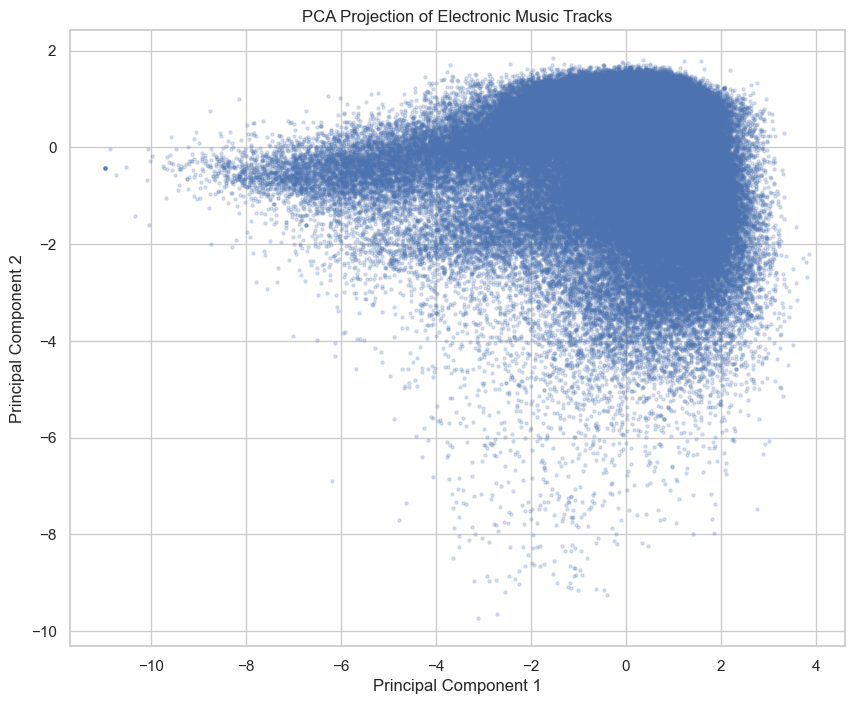

In [33]:
# Visualize PCA projection

plt.figure(figsize=(10,8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=5,
    alpha=0.2
)

plt.title("PCA Projection of Electronic Music Tracks")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

### PCA Structure of the Musical Feature Space

The PCA projection reveals the global structure of the musical feature space.

Most tracks concentrate in a dense central region, indicating that many electronic music tracks share similar musical characteristics.

The triangular shape of the distribution reflects the bounded nature of several Spotify audio features such as danceability, energy and acousticness, which are constrained between 0 and 1.

Some tracks appear in more extreme regions of the projection, suggesting combinations of audio characteristics that differ from the typical patterns found in the dataset.

## PCA Visualization by Genre

The dataset contains more than 30 electronic music genres.  
Displaying all genres simultaneously in a scatter plot would result in a highly cluttered visualization that is difficult to interpret.

To improve readability, the analysis focuses on the **most frequent genres in the dataset**.  
These genres represent a large proportion of the tracks and provide a meaningful overview of how different electronic music styles are positioned in the musical feature space.

The following visualization therefore includes only the **top genres by track count**.

In [37]:
# Add genre information to PCA dataframe

pca_df["genre"] = sample_df["genre_name"].values

# Inspect most frequent genres in the sample

sample_df["genre_name"].value_counts().head(10)

genre_name
Electronica                     31045
Techno (Peak Time / Driving)    23602
House                           19256
Deep House                      13611
Tech House                      13323
Trap / Wave                      9979
Dance / Electro Pop              9429
Progressive House                8942
Drum & Bass                      8163
Minimal / Deep Tech              8130
Name: count, dtype: int64

In [39]:
# Select the most frequent genres

top_genres = sample_df["genre_name"].value_counts().head(10).index

# Filter PCA dataframe to include only the selected genres

pca_top_genres = pca_df[pca_df["genre"].isin(top_genres)]

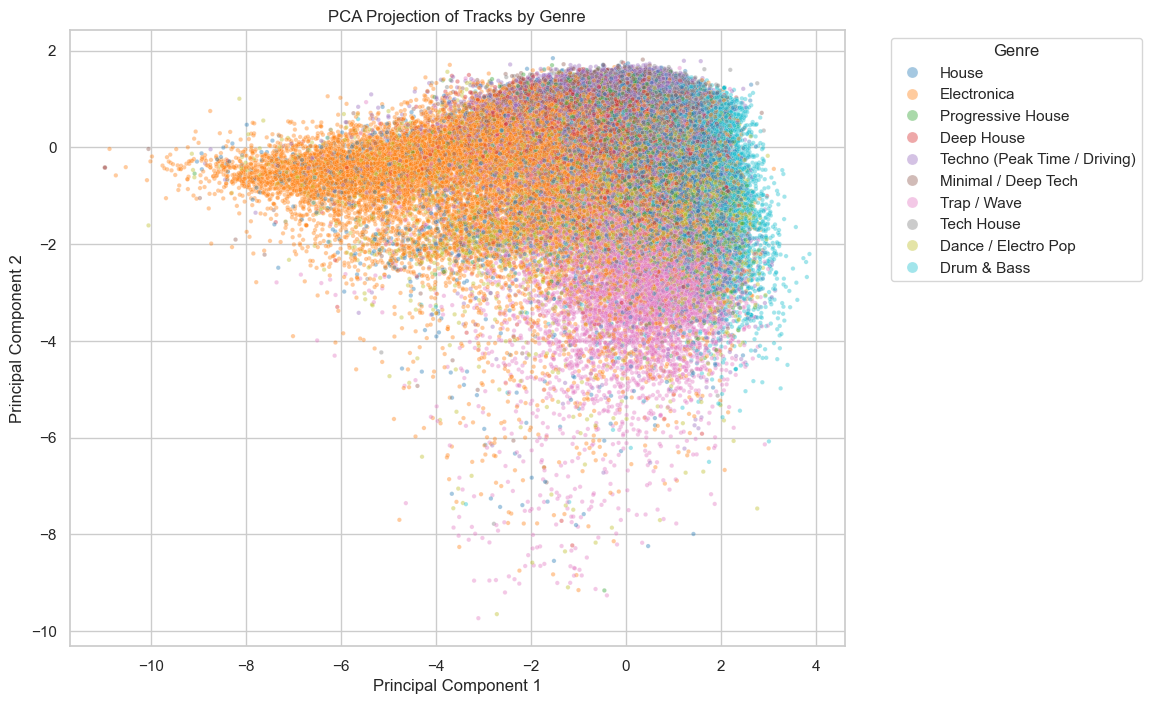

In [73]:
plt.figure(figsize=(10,8))

ax = sns.scatterplot(
    data=pca_top_genres,
    x="PC1",
    y="PC2",
    hue="genre",
    s=10,
    alpha=0.4,
    palette="tab10"
)

plt.title("PCA Projection of Tracks by Genre")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

ax.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left",
    title="Genre",
    fontsize=11,
    title_fontsize=12,
    markerscale=2.5
)

plt.show()

### Observations

The PCA projection suggests that electronic music genres partially overlap in the feature space, but some stylistic tendencies are still visible.

Genres such as **Electronica** occupy broader regions of the projection, reflecting their stylistic diversity.  
In contrast, genres such as **Drum & Bass** and **Trap / Wave** tend to concentrate in more specific regions, indicating stronger feature consistency in the reduced space.

Overall, the visualization suggests that audio features capture meaningful stylistic structure, even though genre boundaries are not fully separated.

In [50]:
# Inspect PCA feature loadings

loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=["PC1", "PC2"]
)

loadings

,PC1,PC2
danceability,0.272876,0.214584
energy,0.521604,0.078861
acousticness,-0.471206,-0.263739
instrumentalness,-0.127055,0.639256
liveness,0.090837,-0.344314
speechiness,0.077103,-0.552393
valence,0.248099,-0.152235
tempo,0.238489,0.106577
loudness,0.531662,-0.106317


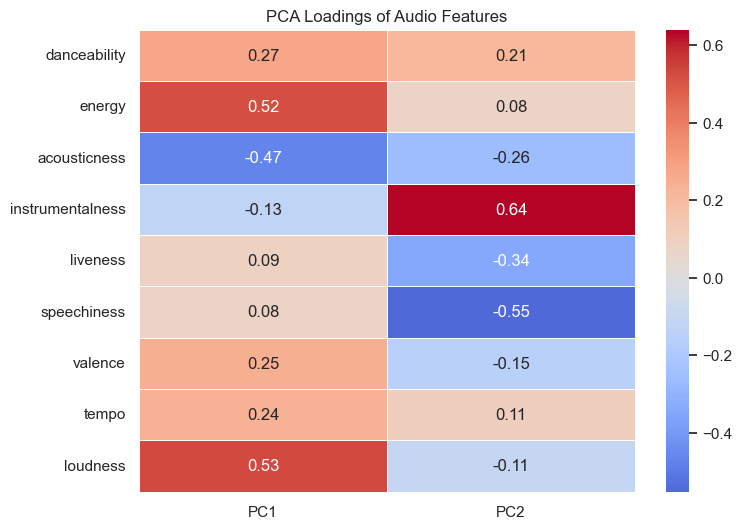

In [52]:
# Visualize PCA loadings

plt.figure(figsize=(8,6))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("PCA Loadings of Audio Features")
plt.show()

### Interpretation of Principal Components

The PCA loadings help interpret the meaning of the two principal components.

**PC1** is strongly associated with loudness and energy (positive loadings) and negatively associated with acousticness.  
This suggests that PC1 captures the **overall intensity of the track**, separating energetic club-oriented music from softer or more acoustic styles.

**PC2** is dominated by instrumentalness (positive loading) and speechiness (negative loading).  
This component therefore reflects the **instrumental vs vocal character of tracks**, distinguishing instrumental electronic genres from vocal-driven styles.

Together, the two components form a meaningful musical space where tracks are organized by **energy/intensity** and **vocal presence**.

## K-Means Clustering

To explore whether electronic music tracks form natural groups in the feature space, we apply **K-Means clustering**.

Before fitting the final model, we evaluate different values of **k** to identify a reasonable number of clusters using the elbow method.

In [56]:
# Compute inertia for different numbers of clusters

inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

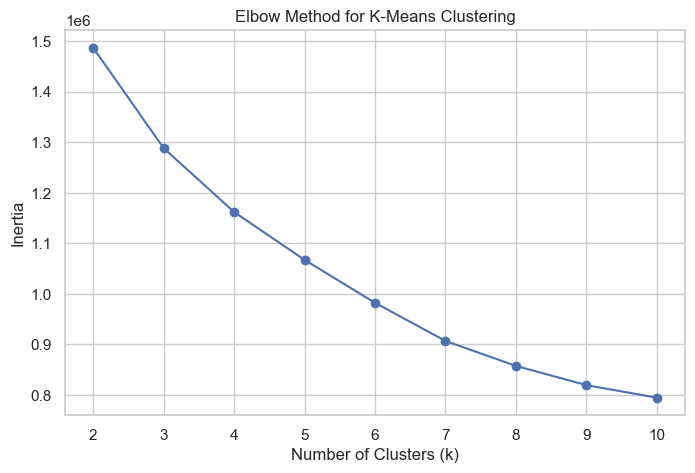

In [58]:
# Visualize the elbow curve

plt.figure(figsize=(8,5))

plt.plot(k_values, inertia_values, marker="o")

plt.title("Elbow Method for K-Means Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.show()

### Choosing the Number of Clusters

The elbow curve shows a clear reduction in inertia between **k = 2 and k = 5**, after which the improvement becomes progressively smaller.

This suggests that the main structure of the data is captured with around **5–6 clusters**.  
For the subsequent analysis, we select **k = 6** to balance model simplicity and descriptive power.

In [63]:
# Fit final KMeans model

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [67]:
# Add cluster labels to the full PCA dataframe

pca_df["cluster"] = clusters

# Filter PCA dataframe for the selected genres

pca_top_genres = pca_df[pca_df["genre"].isin(top_genres)]

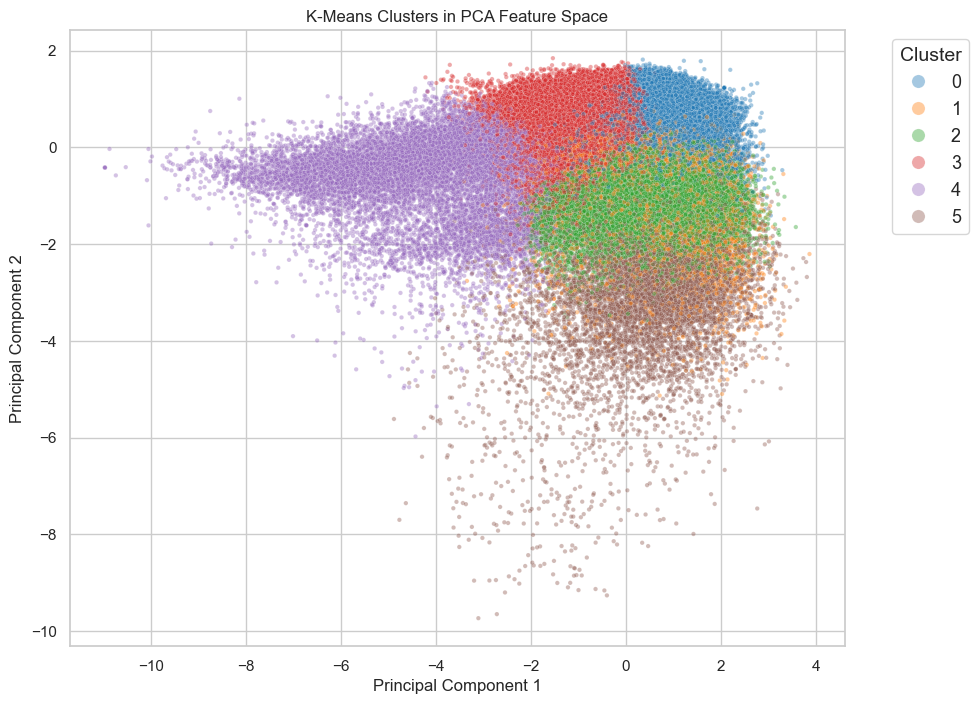

In [81]:
plt.figure(figsize=(10,8))

ax = sns.scatterplot(
    data=pca_top_genres,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=10,
    alpha=0.4
)

plt.title("K-Means Clusters in PCA Feature Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

ax.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left",
    title="Cluster",
    fontsize=13,
    title_fontsize=14,
    markerscale=3
)

plt.show()

### Interpretation of K-Means Clusters

The clustering structure closely follows the geometry of the PCA space.

Clusters located on the **left side of the plot** correspond to tracks with lower energy and higher acoustic characteristics, typically associated with more atmospheric or experimental electronic music.

Clusters on the **right side** represent more energetic and club-oriented tracks, driven by higher loudness and energy levels.

Along the vertical axis, clusters separate tracks according to their **instrumental versus vocal character**.  
Upper regions tend to contain more instrumental tracks, while lower regions are associated with higher speechiness and stronger vocal presence.

Overall, the clustering reveals a meaningful organization of electronic music tracks based on two main musical dimensions: **energy/intensity and vocal presence**.

## Relationship Between Clusters and Genres

After identifying clusters in the feature space, the next step is to examine how these clusters relate to the original **music genres**.

While the clustering algorithm was trained solely on audio features (without using genre labels), we can compare the resulting clusters with the genre information to better understand what musical styles each cluster may represent.

To do this, we analyze the **distribution of genres within each cluster**, which allows us to identify whether certain genres dominate specific regions of the feature space.

In [85]:
cluster_genre_table = pd.crosstab(
    pca_top_genres["cluster"],
    pca_top_genres["genre"]
)

cluster_genre_table

genre,Dance / Electro Pop,Deep House,Drum & Bass,Electronica,House,Minimal / Deep Tech,Progressive House,Tech House,Techno (Peak Time / Driving),Trap / Wave
cluster,,,,,,,,,,
0,1619,3801,4401,5588,6598,2834,3376,6809,10815,518
1,727,684,1389,1868,1453,327,1088,923,1979,402
2,4422,1869,1083,4753,5830,229,1333,954,796,3266
3,1163,6842,416,8164,4080,4506,2972,4468,8933,824
4,1018,221,78,9382,758,128,54,58,587,512
5,480,194,796,1290,537,106,119,111,492,4457


### Cluster–Genre Relationship

The cluster–genre table shows that clusters do not correspond strictly to individual genres.  
Instead, clusters group tracks according to **shared musical characteristics**.

Some clusters are dominated by specific genres (for example, the cluster containing a large proportion of Trap / Wave tracks), while others mix multiple related genres such as House, Tech House and Techno.

This suggests that the clustering algorithm is capturing **underlying musical dimensions** rather than rigid genre boundaries.  
In other words, the model groups tracks by **sound characteristics**, not by the genre labels assigned by humans.

In [88]:
cluster_genre_ratio = pd.crosstab(
    pca_top_genres["cluster"],
    pca_top_genres["genre"],
    normalize="index"
)

cluster_genre_ratio.round(2)

genre,Dance / Electro Pop,Deep House,Drum & Bass,Electronica,House,Minimal / Deep Tech,Progressive House,Tech House,Techno (Peak Time / Driving),Trap / Wave
cluster,,,,,,,,,,
0,0.03,0.08,0.09,0.12,0.14,0.06,0.07,0.15,0.23,0.01
1,0.07,0.06,0.13,0.17,0.13,0.03,0.10,0.09,0.18,0.04
2,0.18,0.08,0.04,0.19,0.24,0.01,0.05,0.04,0.03,0.13
3,0.03,0.16,0.01,0.19,0.10,0.11,0.07,0.11,0.21,0.02
4,0.08,0.02,0.01,0.73,0.06,0.01,0.00,0.00,0.05,0.04
5,0.06,0.02,0.09,0.15,0.06,0.01,0.01,0.01,0.06,0.52


### Cluster Interpretation

The normalized cluster–genre table highlights how different genres are distributed across clusters.

Some clusters show strong dominance of specific genres. For example, one cluster contains a large proportion of **Trap / Wave tracks**, while another is heavily dominated by **Electronica**.

However, many clusters contain mixtures of related genres such as **House, Tech House, and Techno**. This indicates that the clustering algorithm is not reproducing genre labels directly, but instead grouping tracks according to **shared musical characteristics**.

Overall, the clusters reflect underlying musical dimensions such as **energy level, vocal presence, and instrumental character**, rather than strict genre boundaries.

## Conclusion

This analysis explored the structure of electronic music using audio features derived from Spotify tracks.

Using **Principal Component Analysis (PCA)**, we projected high-dimensional audio features into a two-dimensional space, revealing meaningful musical dimensions. The first component mainly captured **energy and loudness**, while the second component reflected the balance between **instrumental and vocal characteristics**.

Applying **K-Means clustering** allowed us to identify distinct regions in this feature space. These clusters did not correspond strictly to individual genres, but instead represented broader **musical characteristics**, such as energetic club-oriented tracks, atmospheric electronic music, or vocal-driven styles.

The results highlight how audio features can reveal **underlying structures in electronic music**, offering a data-driven perspective on how different styles relate to each other.

Overall, this approach demonstrates how dimensionality reduction and clustering techniques can help uncover patterns in large-scale music datasets.